Notebook 04 – Feature Engineering

- Objective

The objective of this notebook is to transform cleaned metadata and image quality measurements into a unified feature dataset for machine learning.

The engineered features generated in this notebook will serve as inputs to the baseline models and subsequently support the AI Trust Score framework.

- Input : - master_metadata.csv, - image_quality_features.csv

- Output : - feature_dataset.csv, - feature_summary.csv, - feature_correlation.csv, - feature_list.csv

In [28]:
from pathlib import Path

DATA_DIR = Path("../data")
PROCESSED_DIR = DATA_DIR / "processed"

OUTPUT_DIR = Path("../outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

In [30]:
metadata = pd.read_csv(
    PROCESSED_DIR / "master_metadata.csv"
)

quality = pd.read_csv(
    PROCESSED_DIR / "image_quality_features.csv"
)

print(metadata.shape)
print(quality.shape)

(36307, 10)
(36307, 4)


In [31]:
features = metadata.merge(
    quality,
    on="image_path",
    how="left"
)

print(features.shape)

features.head()

(36307, 13)


,dataset,image_path,file_name,extension,valid_image,size_mb,resolution,width,height,aspect_ratio,brightness,contrast,blur_score
0,ADMS,../data/raw/adms/Valid/images/c_-308-_jpg.rf.0...,c_-308-_jpg.rf.0b71b13d1c0db0ac91b0997247d22a4...,.jpg,True,0.036607,"(640, 512)",640,512,1.250000,101.796115,77.421768,303.034534
1,ADMS,../data/raw/adms/Valid/images/112_jpg.rf.93fc7...,112_jpg.rf.93fc71b2c98ad78087aaf17c7778f857.jpg,.jpg,True,0.023131,"(640, 480)",640,480,1.333333,117.716758,83.798998,102.319757
2,ADMS,../data/raw/adms/Valid/images/CHANNEL_03_20220...,CHANNEL_03_20220509152715_20220509152725_mp4-8...,.jpg,True,0.018838,"(640, 384)",640,384,1.666667,34.701331,31.426948,2054.328330
3,ADMS,../data/raw/adms/Valid/images/358_jpg.rf.0bc5f...,358_jpg.rf.0bc5fd26b9209862fe5336d1cacb2ed8.jpg,.jpg,True,0.031053,"(640, 427)",640,427,1.498829,191.340501,45.981054,535.900534
4,ADMS,../data/raw/adms/Valid/images/_-3-_mp4-96_jpg....,_-3-_mp4-96_jpg.rf.5a65ec89c93eaf85c76b0530bda...,.jpg,True,0.020555,"(640, 523)",640,523,1.223709,58.986230,60.506965,739.359342


In [32]:
print(features.isnull().sum())

print(features.duplicated().sum())

dataset         0
image_path      0
file_name       0
extension       0
valid_image     0
size_mb         0
resolution      0
width           0
height          0
aspect_ratio    0
brightness      0
contrast        0
blur_score      0
dtype: int64
0


In [33]:
features["image_area"] = (
    features["width"] *
    features["height"]
)

features["size_per_pixel"] = (
    features["size_mb"] /
    features["image_area"]
)

features["is_square"] = (
    np.isclose(
        features["aspect_ratio"],
        1.0,
        atol=0.05
    )
).astype(int)

In [34]:
features = pd.get_dummies(
    features,
    columns=["dataset"],
    dtype=int
)

In [ ]:
summary = features.describe()

display(summary)

summary.to_csv(
    TABLE_DIR / "feature_summary.csv"
)

In [35]:
feature_list = pd.DataFrame({

    "Feature": features.columns

})

feature_list.to_csv(
    TABLE_DIR / "feature_list.csv",
    index=False
)

feature_list

,Feature
0,image_path
1,file_name
2,extension
3,valid_image
4,size_mb
5,resolution
6,width
7,height
8,aspect_ratio
9,brightness


In [36]:
numeric_columns = features.select_dtypes(
    include=np.number
).columns

scaler = StandardScaler()

features[numeric_columns] = scaler.fit_transform(
    features[numeric_columns]
)

,valid_image,size_mb,width,height,aspect_ratio,brightness,contrast,blur_score,image_area,size_per_pixel,is_square,dataset_ADMS,dataset_Drowsiness,dataset_StateFarm
valid_image,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
size_mb,NaN,1.000000,0.527680,0.554166,0.302655,0.082595,0.606081,0.445375,0.441352,-0.409076,-0.657072,0.258312,-0.803423,0.281038
width,NaN,0.527680,1.000000,0.844054,0.611260,-0.306119,0.000464,0.037548,0.919431,-0.949801,-0.383924,0.905642,-0.576343,-0.458161
height,NaN,0.554166,0.844054,1.000000,0.120638,-0.117153,0.071243,-0.151271,0.956660,-0.865767,-0.197108,0.823414,-0.501843,-0.430847
aspect_ratio,NaN,0.302655,0.611260,0.120638,1.000000,-0.369428,0.092906,0.437095,0.263157,-0.496187,-0.597675,0.398063,-0.520408,-0.029302
brightness,NaN,0.082595,-0.306119,-0.117153,-0.369428,1.000000,0.261368,-0.130475,-0.208757,0.324033,0.120428,-0.316971,0.085475,0.235248
contrast,NaN,0.606081,0.000464,0.071243,0.092906,0.261368,1.000000,0.533186,-0.103512,0.046230,-0.617080,-0.349829,-0.719453,0.783941
blur_score,NaN,0.445375,0.037548,-0.151271,0.437095,-0.130475,0.533186,1.000000,-0.206385,0.069291,-0.617888,-0.245721,-0.546582,0.577210
image_area,NaN,0.441352,0.919431,0.956660,0.263157,-0.208757,-0.103512,-0.206385,1.000000,-0.917044,-0.106884,0.930270,-0.392652,-0.599067
size_per_pixel,NaN,-0.409076,-0.949801,-0.865767,-0.496187,0.324033,0.046230,0.069291,-0.917044,1.000000,0.338668,-0.898862,0.538389,0.476404


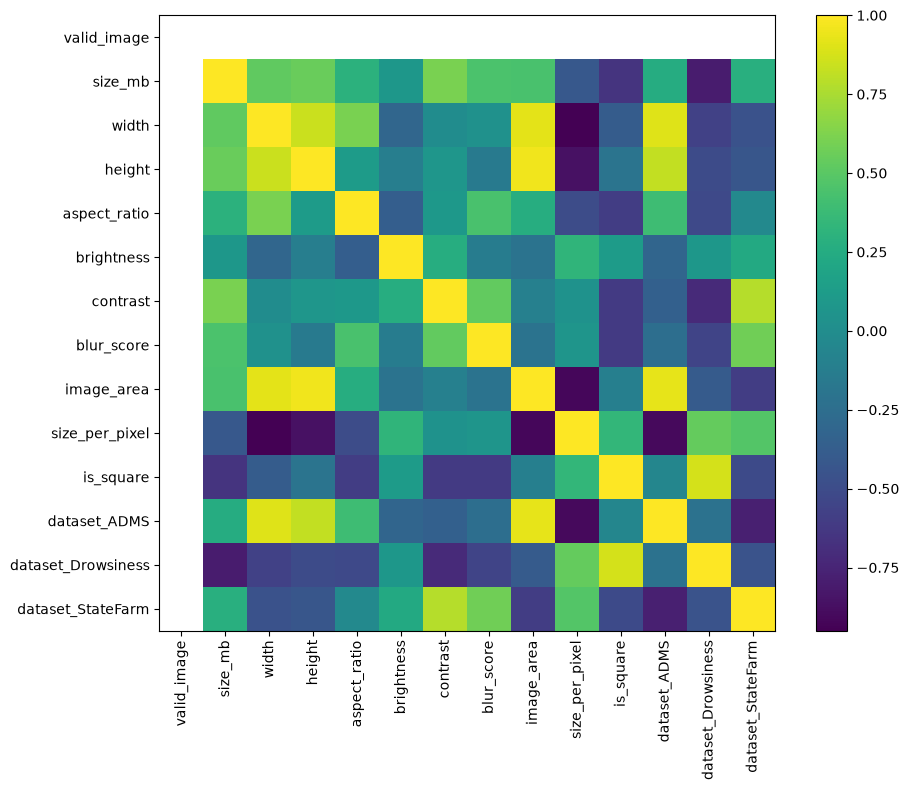

In [37]:
corr = features.corr(
    numeric_only=True
)

display(corr)

corr.to_csv(
    TABLE_DIR / "feature_correlation.csv"
)

plt.figure(figsize=(10,8))

plt.imshow(corr)

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.colorbar()

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "feature_correlation.png",
    dpi=300
)

plt.show()

In [38]:
features.to_csv(
    PROCESSED_DIR / "feature_dataset.csv",
    index=False
)

print("Feature dataset saved successfully.")

Feature dataset saved successfully.


In [39]:
print("="*60)

print("FEATURE ENGINEERING SUMMARY")

print("="*60)

print(f"Total Samples : {len(features)}")

print(f"Total Features : {features.shape[1]}")

print(f"Missing Values : {features.isnull().sum().sum()}")

print(f"Duplicate Rows : {features.duplicated().sum()}")

print("\nNotebook 4 Complete ✔")

FEATURE ENGINEERING SUMMARY
Total Samples : 36307
Total Features : 18
Missing Values : 0
Duplicate Rows : 0

Notebook 4 Complete ✔


 Key Observations

- Observation 1: Image metadata and image quality metrics were successfully integrated into a unified feature dataset.

- Observation 2: Additional engineered features, including image area, size per pixel, and image shape indicators, were derived to enrich the dataset.

- Observation 3: Categorical dataset identifiers were transformed using one-hot encoding to enable machine learning algorithms to utilize dataset-specific information.

- Observation 4: Feature normalization standardized numerical variables, ensuring consistent scales for downstream model training.


Research Implication - The resulting feature dataset provides a comprehensive representation of image metadata, quality characteristics, and engineered attributes, establishing a robust foundation for baseline model development and the subsequent AI Trust Score framework.